<a href="https://colab.research.google.com/github/kungumabalaji/balaji-/blob/main/kunguma_balaji_wintermute.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Make plots pretty
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Step 2: Load the dataset
df = pd.read_csv("/content/wintermute_transfers_search_default_2025-04-08.csv")

# Step 3: Preview the dataset
df.head()

,timestamp,from_address,from_entity,to_address,to_entity,token,value,usd,tx_hash,chain,block_number
0,2025-04-08 12:49:57+00:00,0xB1026b8e7276e7AC75410F1fcbbe21796e8f7526,Camelot,0x51C72848c68a965f66FA7a88855F9f7784502a7F,Wintermute,USDC,438.108563,438.108563,0x98058c529466064c355bdfea3cfebe399344678f20bb...,arbitrum_one,324218955.0
1,2025-04-08 12:49:54+00:00,0xcDa53B1F66614552F834cEeF361A8D12a0B8DaD8,Uniswap,0x51C72848c68a965f66FA7a88855F9f7784502a7F,Wintermute,ARB,3837.138536,1062.879700,0x405b146ac6a52b93e5a77760a4b49a87015b5c5e0659...,arbitrum_one,324218945.0
2,2025-04-08 12:49:51+00:00,0xb2cc224c1c9feE385f8ad6a55b4d94E92359DC59,Aerodrome Finance,0x51C72848c68a965f66FA7a88855F9f7784502a7F,Wintermute,WETH,7.345922,11533.612401,0x7f370fc61bed7241d846c4907a4e616e69ce60ff0192...,base,28663622.0
3,2025-04-08 12:49:51+00:00,0x51C72848c68a965f66FA7a88855F9f7784502a7F,Wintermute,0x72AB388E2E2F6FaceF59E3C3FA2C4E29011c2D38,PancakeSwap,USDC,2143.712587,2143.712587,0x88b4fb948e95cc2b9a22c48efe3d6a6788209302e72f...,base,28663622.0
4,2025-04-08 12:49:50+00:00,0x641C00A822e8b671738d32a431a4Fb6074E5c79d,Uniswap,0x51C72848c68a965f66FA7a88855F9f7784502a7F,Wintermute,WETH,0.470011,737.550466,0x39fc603c882c2f5af51b7f8cfc8eb58753f5e42eff94...,arbitrum_one,324218918.0


In [2]:
# Step 1: Extract all from/to entities where Wintermute is involved
wintermute_mask = (df["from_entity"] == "Wintermute") | (df["to_entity"] == "Wintermute")

# Get unique counterparties (entities Wintermute interacted with)
counterparties = pd.concat([
    df.loc[df["from_entity"] == "Wintermute", "to_entity"],
    df.loc[df["to_entity"] == "Wintermute", "from_entity"]
]).dropna().unique()

# Step 2: Convert to DataFrame for classification
entities_df = pd.DataFrame(counterparties, columns=["entity"])
entities_df = entities_df.drop_duplicates().reset_index(drop=True)
entities_df.head(10)

,entity
0,PancakeSwap
1,Uniswap
2,CoW Protocol
3,Fluid (Instadapp)
4,Orca
5,Aerodrome Finance
6,Raydium
7,Jito
8,Meteora (Prev. Mercurial)
9,Camelot


In [3]:
# Step 3: Create a basic DeFi vs Non-DeFi map
defi_list = [
    "Uniswap", "Camelot", "Curve", "Balancer", "1inch", "SushiSwap",
    "PancakeSwap", "Aave", "Compound", "Aerodrome Finance"
]

# Classify each entity
entities_df["type"] = entities_df["entity"].apply(
    lambda x: "DeFi" if x in defi_list else "Non-DeFi"
)

entities_df.head(10)


,entity,type
0,PancakeSwap,DeFi
1,Uniswap,DeFi
2,CoW Protocol,Non-DeFi
3,Fluid (Instadapp),Non-DeFi
4,Orca,Non-DeFi
5,Aerodrome Finance,DeFi
6,Raydium,Non-DeFi
7,Jito,Non-DeFi
8,Meteora (Prev. Mercurial),Non-DeFi
9,Camelot,DeFi


In [4]:
counterparties = pd.concat([
    df.loc[df["from_entity"] == "Wintermute", "to_entity"],
    df.loc[df["to_entity"] == "Wintermute", "from_entity"]
]).dropna().unique()


In [5]:
# Re-create the counterparties (in case not stored)
counterparties = pd.concat([
    df.loc[df["from_entity"] == "Wintermute", "to_entity"],
    df.loc[df["to_entity"] == "Wintermute", "from_entity"]
]).dropna().unique()

# Convert to DataFrame so it's readable
entities_df = pd.DataFrame(counterparties, columns=["entity"])

# Show the first 20 counterparties
entities_df.head(20)


,entity
0,PancakeSwap
1,Uniswap
2,CoW Protocol
3,Fluid (Instadapp)
4,Orca
5,Aerodrome Finance
6,Raydium
7,Jito
8,Meteora (Prev. Mercurial)
9,Camelot


In [6]:
# STEP 1: Get all unique counterparties that Wintermute interacted with
counterparties = pd.concat([
    df.loc[df["from_entity"] == "Wintermute", "to_entity"],
    df.loc[df["to_entity"] == "Wintermute", "from_entity"]
]).dropna().unique()

# STEP 2: Convert to DataFrame
entities_df = pd.DataFrame(counterparties, columns=["entity"])

# STEP 3: Clean up entity names for better matching
entities_df["entity_clean"] = entities_df["entity"].str.lower().str.replace(".fi", "", regex=False)
entities_df["entity_clean"] = entities_df["entity_clean"].str.replace(r"[^\w\s]", "", regex=True).str.strip()

# STEP 4: Define list of known DeFi platforms (all lowercase, cleaned up)
defi_entities_clean = [
    "uniswap", "camelot", "curve", "balancer", "1inch", "sushiswap", "pancakeswap",
    "aave", "compound", "cow protocol", "aerodrome finance", "instadapp", "paraswap"
]

# STEP 5: Classify as DeFi or Non-DeFi
entities_df["type"] = entities_df["entity_clean"].apply(
    lambda x: "DeFi" if x in defi_entities_clean else "Non-DeFi"
)

# STEP 6: Drop helper column if not needed (optional)
entities_df.drop(columns=["entity_clean"], inplace=True)

# STEP 7: Show the first 20 classified entities
entities_df.head(20)

,entity,type
0,PancakeSwap,DeFi
1,Uniswap,DeFi
2,CoW Protocol,DeFi
3,Fluid (Instadapp),Non-DeFi
4,Orca,Non-DeFi
5,Aerodrome Finance,DeFi
6,Raydium,Non-DeFi
7,Jito,Non-DeFi
8,Meteora (Prev. Mercurial),Non-DeFi
9,Camelot,DeFi


In [7]:
# Show all unique entities Wintermute interacted with and their classification
pd.set_option('display.max_rows', None)  # Show all rows, not just 20
entities_df.sort_values("type", ascending=False).reset_index(drop=True)

,entity,type
0,Coinbase,Non-DeFi
1,Odos,Non-DeFi
2,@yo_ji12345,Non-DeFi
3,@IceSapp45,Non-DeFi
4,Arctic Bastion (1inch Resolver),Non-DeFi
5,@AnonPartTime,Non-DeFi
6,@inicola86,Non-DeFi
7,@TrueNFT33,Non-DeFi
8,@ec1ipse_sol,Non-DeFi
9,@SolanaSeeker,Non-DeFi


In [8]:
# STEP: Get list of DeFi entity names (from classified table)
defi_only_entities = entities_df[entities_df["type"] == "DeFi"]["entity"].tolist()

# STEP: Filter the main dataframe to keep only transactions with DeFi entities
defi_df = df[
    ((df["from_entity"] == "Wintermute") & (df["to_entity"].isin(defi_only_entities))) |
    ((df["to_entity"] == "Wintermute") & (df["from_entity"].isin(defi_only_entities)))
].copy()

# Preview the filtered DeFi-only dataset
defi_df.head()


,timestamp,from_address,from_entity,to_address,to_entity,token,value,usd,tx_hash,chain,block_number
0,2025-04-08 12:49:57+00:00,0xB1026b8e7276e7AC75410F1fcbbe21796e8f7526,Camelot,0x51C72848c68a965f66FA7a88855F9f7784502a7F,Wintermute,USDC,438.108563,438.108563,0x98058c529466064c355bdfea3cfebe399344678f20bb...,arbitrum_one,324218955.0
1,2025-04-08 12:49:54+00:00,0xcDa53B1F66614552F834cEeF361A8D12a0B8DaD8,Uniswap,0x51C72848c68a965f66FA7a88855F9f7784502a7F,Wintermute,ARB,3837.138536,1062.879700,0x405b146ac6a52b93e5a77760a4b49a87015b5c5e0659...,arbitrum_one,324218945.0
2,2025-04-08 12:49:51+00:00,0xb2cc224c1c9feE385f8ad6a55b4d94E92359DC59,Aerodrome Finance,0x51C72848c68a965f66FA7a88855F9f7784502a7F,Wintermute,WETH,7.345922,11533.612401,0x7f370fc61bed7241d846c4907a4e616e69ce60ff0192...,base,28663622.0
3,2025-04-08 12:49:51+00:00,0x51C72848c68a965f66FA7a88855F9f7784502a7F,Wintermute,0x72AB388E2E2F6FaceF59E3C3FA2C4E29011c2D38,PancakeSwap,USDC,2143.712587,2143.712587,0x88b4fb948e95cc2b9a22c48efe3d6a6788209302e72f...,base,28663622.0
4,2025-04-08 12:49:50+00:00,0x641C00A822e8b671738d32a431a4Fb6074E5c79d,Uniswap,0x51C72848c68a965f66FA7a88855F9f7784502a7F,Wintermute,WETH,0.470011,737.550466,0x39fc603c882c2f5af51b7f8cfc8eb58753f5e42eff94...,arbitrum_one,324218918.0


In [9]:
# Count how often each token was traded
token_freq = defi_df["token"].value_counts().reset_index()
token_freq.columns = ["token", "frequency"]

# Total USD volume per token
token_volume = defi_df.groupby("token")["usd"].sum().reset_index().sort_values(by="usd", ascending=False)

# Merge both into one view
token_stats = pd.merge(token_freq, token_volume, on="token")
token_stats.head(10)

,token,frequency,usd
0,WETH,34181,2.298839e+08
1,USDC,27732,1.800717e+08
2,USDT,9157,5.991266e+07
3,WBTC,5812,3.548486e+07
4,ARB,5316,2.834032e+06
5,cbBTC,4503,4.400151e+07
6,WBNB,2796,1.022791e+07
7,BTCB,933,6.503547e+06
8,EURC,622,3.141355e+06
9,USDbC,527,6.250087e+05


In [10]:
# Already have frequency and volume per token
# Let’s set a threshold: "preferred" = above median frequency or volume
freq_median = token_stats["frequency"].median()
vol_median = token_stats["usd"].median()

token_stats["preference"] = token_stats.apply(
    lambda row: "preferred" if (row["frequency"] > freq_median or row["usd"] > vol_median) else "less used",
    axis=1
)

token_stats.sort_values(by="frequency", ascending=False).head(90)

,token,frequency,usd,preference
0,WETH,34181,2.298839e+08,preferred
1,USDC,27732,1.800717e+08,preferred
2,USDT,9157,5.991266e+07,preferred
3,WBTC,5812,3.548486e+07,preferred
4,ARB,5316,2.834032e+06,preferred
5,cbBTC,4503,4.400151e+07,preferred
6,WBNB,2796,1.022791e+07,preferred
7,BTCB,933,6.503547e+06,preferred
8,EURC,622,3.141355e+06,preferred
9,USDbC,527,6.250087e+05,preferred


In [ ]:
from matplotlib import pyplot as plt
_df_24['frequency'].plot(kind='hist', bins=20, title='frequency')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [12]:
# Count transactions by chain
chain_activity = defi_df["chain"].value_counts().reset_index()
chain_activity.columns = ["chain", "tx_count"]

# Total volume per chain
chain_volume = defi_df.groupby("chain")["usd"].sum().reset_index().sort_values(by="usd", ascending=False)

# Combine both
chain_stats = pd.merge(chain_activity, chain_volume, on="chain")
chain_stats


,chain,tx_count,usd
0,arbitrum_one,53538,3.931829e+07
1,base,20433,1.485001e+08
2,ethereum,15372,3.730563e+08
3,bsc,7389,3.244404e+07
4,optimism,988,6.747799e+05


In [13]:
# We use the 'to_entity' or 'from_entity' depending on direction
# We'll collect all counterparties they interacted with (that are DeFi)
defi_entities_in_tx = pd.concat([
    defi_df.loc[defi_df["from_entity"] == "Wintermute", "to_entity"],
    defi_df.loc[defi_df["to_entity"] == "Wintermute", "from_entity"]
])

platform_counts = defi_entities_in_tx.value_counts().reset_index()
platform_counts.columns = ["platform", "interaction_count"]
platform_counts.head(10)


,platform,interaction_count
0,Uniswap,51477
1,PancakeSwap,21608
2,Camelot,10729
3,Aerodrome Finance,9002
4,CoW Protocol,2155
5,ParaSwap,1557
6,Curve.fi,880
7,SushiSwap,292
8,1inch,20


<ipython-input-14-852b0362bf21>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_platforms, x='interaction_count', y='platform', palette='mako')
<ipython-input-14-852b0362bf21>:24: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


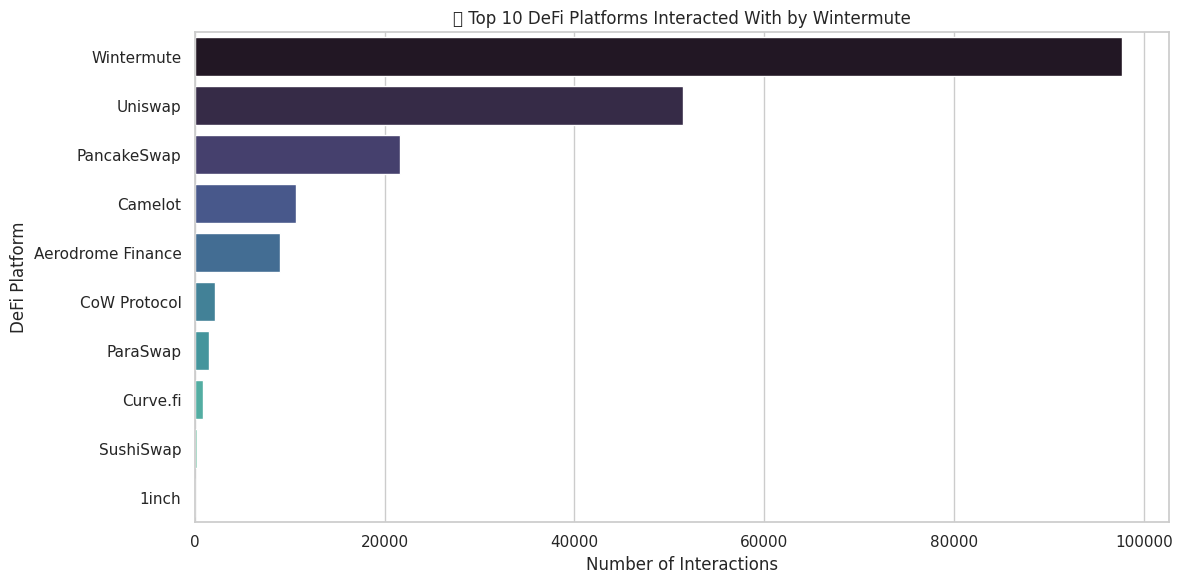

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Count how many times each platform appeared in from_entity or to_entity
# We'll combine both directions

platforms = pd.concat([
    defi_df[['from_entity']].rename(columns={'from_entity': 'platform'}),
    defi_df[['to_entity']].rename(columns={'to_entity': 'platform'})
])

# Step 2: Group by platform name and count interactions
platform_summary = platforms.groupby('platform').size().reset_index(name='interaction_count')

# Step 3: Sort and select top 10 platforms
top_platforms = platform_summary.sort_values(by='interaction_count', ascending=False).head(10)

# Step 4: Plot the result
plt.figure(figsize=(12,6))
sns.barplot(data=top_platforms, x='interaction_count', y='platform', palette='mako')
plt.title('🔝 Top 10 DeFi Platforms Interacted With by Wintermute')
plt.xlabel('Number of Interactions')
plt.ylabel('DeFi Platform')
plt.tight_layout()
plt.show()

In [15]:
# Filter out self-interactions (Wintermute to Wintermute)
defi_df_no_self = defi_df[~((defi_df['from_entity'] == 'Wintermute') & (defi_df['to_entity'] == 'Wintermute'))]


<ipython-input-16-dd0afb4a2d7f>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_platforms_clean, x='interaction_count', y='platform', palette='mako')
<ipython-input-16-dd0afb4a2d7f>:20: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


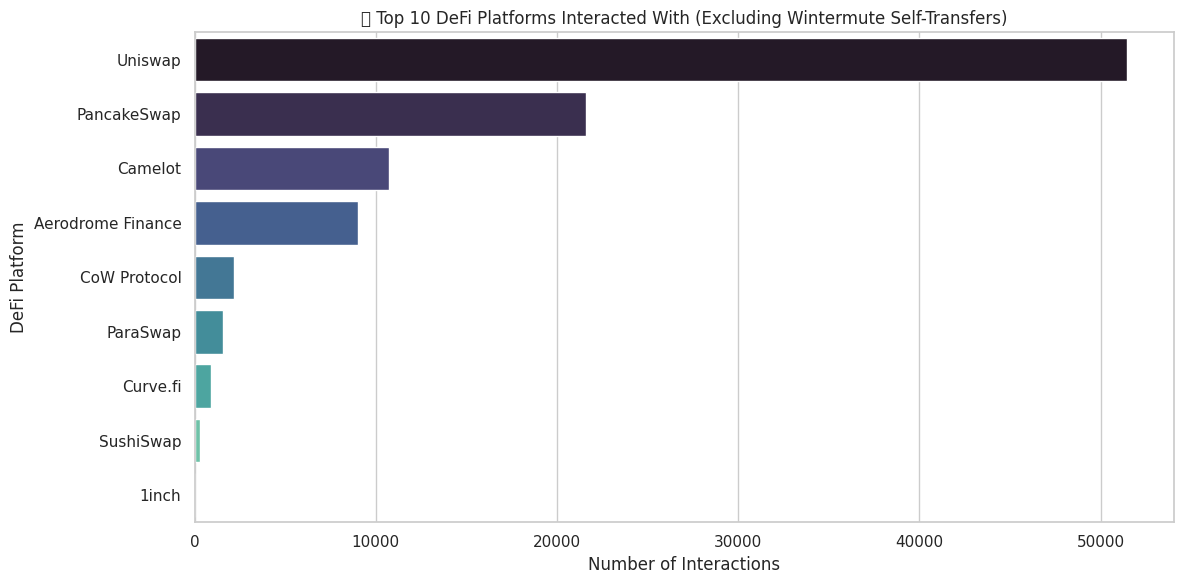

In [16]:
# Combine platform names (from and to)
platforms_clean = pd.concat([
    defi_df_no_self[['from_entity']].rename(columns={'from_entity': 'platform'}),
    defi_df_no_self[['to_entity']].rename(columns={'to_entity': 'platform'})
])

# Remove Wintermute as a counterparty
platforms_clean = platforms_clean[platforms_clean['platform'] != 'Wintermute']

# Count, sort, and plot
platform_summary_clean = platforms_clean.groupby('platform').size().reset_index(name='interaction_count')
top_platforms_clean = platform_summary_clean.sort_values(by='interaction_count', ascending=False).head(10)

# Plot again
plt.figure(figsize=(12,6))
sns.barplot(data=top_platforms_clean, x='interaction_count', y='platform', palette='mako')
plt.title('🔝 Top 10 DeFi Platforms Interacted With (Excluding Wintermute Self-Transfers)')
plt.xlabel('Number of Interactions')
plt.ylabel('DeFi Platform')
plt.tight_layout()
plt.show()

<ipython-input-17-241ce6b48e20>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_tokens, x='count', y='token', palette='viridis')
<ipython-input-17-241ce6b48e20>:15: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


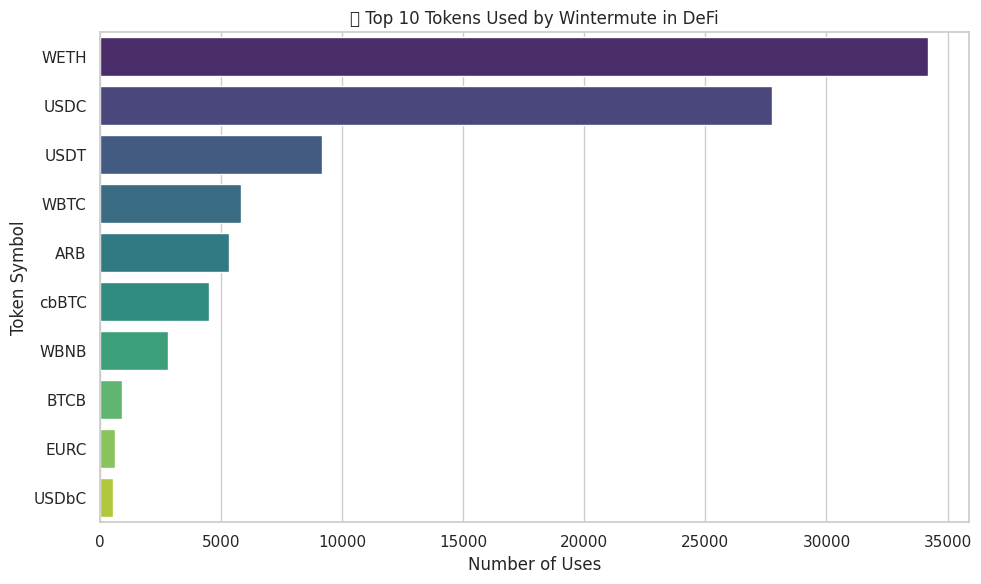

In [17]:
# Drop missing or empty token names
token_counts = defi_df['token'].dropna()
token_counts = token_counts[token_counts != '']

# Count and sort
top_tokens = token_counts.value_counts().head(10).reset_index()
top_tokens.columns = ['token', 'count']

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_tokens, x='count', y='token', palette='viridis')
plt.title('💰 Top 10 Tokens Used by Wintermute in DeFi')
plt.xlabel('Number of Uses')
plt.ylabel('Token Symbol')
plt.tight_layout()
plt.show()


<ipython-input-18-f78a65c2d96a>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chain_counts, x='count', y='chain', palette='rocket')
<ipython-input-18-f78a65c2d96a>:11: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


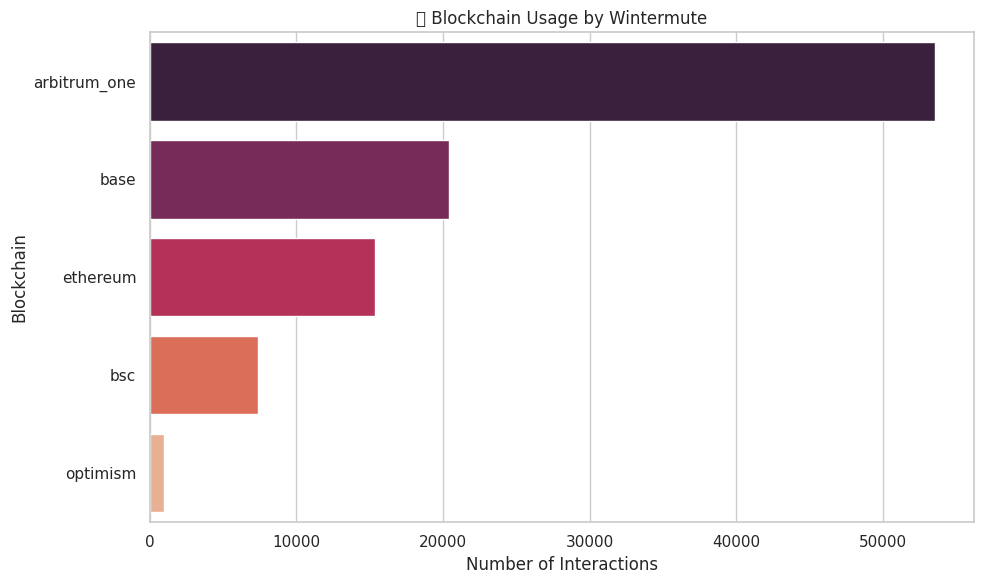

In [18]:
# Count interactions by blockchain
chain_counts = defi_df['chain'].value_counts().reset_index()
chain_counts.columns = ['chain', 'count']

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=chain_counts, x='count', y='chain', palette='rocket')
plt.title('🧬 Blockchain Usage by Wintermute')
plt.xlabel('Number of Interactions')
plt.ylabel('Blockchain')
plt.tight_layout()
plt.show()

<ipython-input-19-baa56b66e657>:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_volume = df['usd'].resample('H').sum()


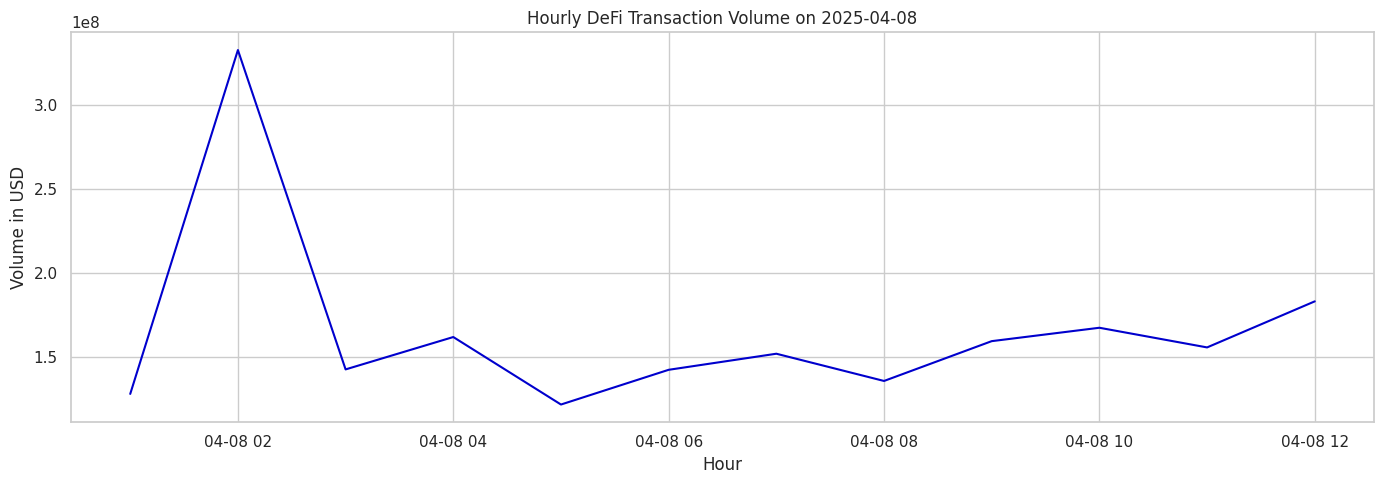

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and clean data
df = pd.read_csv("wintermute_transfers_search_default_2025-04-08.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df['usd'] = pd.to_numeric(df['usd'], errors='coerce')
df = df.dropna(subset=['timestamp', 'usd'])

# Set index and resample by hour
df.set_index('timestamp', inplace=True)
hourly_volume = df['usd'].resample('H').sum()

# Plot
plt.figure(figsize=(14, 5))
plt.plot(hourly_volume, color='mediumblue')
plt.title("Hourly DeFi Transaction Volume on 2025-04-08")
plt.xlabel("Hour")
plt.ylabel("Volume in USD")
plt.grid(True)
plt.tight_layout()
plt.show()